# Noise2Void for STEM Image Denoising 

## Libraries

In [1]:
import os
import random
import logging
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm 

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger("n2v")

%matplotlib inline

In [3]:
# GPU: Check 
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        # CPU fallback for any ops not yet implemented on MPS
        os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print(f"Device: {device}")
if device.type == "mps":
    print("Apple Metal (MPS) is active — training on GPU.")

Device: mps
Apple Metal (MPS) is active — training on GPU.


## 2. U-Net model + N2V masking & loss

Standard U-Net (depth=4, base=64) adapted for 1-channel grayscale STEM images.

In [6]:
class DoubleConv(nn.Module):
    
    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        mid_ch = mid_ch or out_ch
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch, in_ch // 2)
        else:
            self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        dy = x2.size(2) - x1.size(2)
        dx = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x2, x1], dim=1))


class N2VUNet(nn.Module):
    """U-Net backbone for Noise2Void."""
    def __init__(self, in_channels=1, out_channels=1, base_features=64, bilinear=True):
        super().__init__()
        f = base_features
        self.inc   = DoubleConv(in_channels, f)
        self.down1 = Down(f,      f * 2)
        self.down2 = Down(f * 2,  f * 4)
        self.down3 = Down(f * 4,  f * 8)
        self.down4 = Down(f * 8,  f * 16 // (2 if bilinear else 1))
        self.up1   = Up(f * 16, f * 8 // (2 if bilinear else 1), bilinear)
        self.up2   = Up(f * 8,  f * 4 // (2 if bilinear else 1), bilinear)
        self.up3   = Up(f * 4,  f * 2 // (2 if bilinear else 1), bilinear)
        self.up4   = Up(f * 2,  f,                                bilinear)
        self.outc  = nn.Conv2d(f, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x  = self.up1(x5, x4)
        x  = self.up2(x,  x3)
        x  = self.up3(x,  x2)
        x  = self.up4(x,  x1)
        return self.outc(x)

In [8]:
def n2v_mask(patch, mask_pixel_perc=0.02, neighborhood_radius=5):
  
  
    B, C, H, W = patch.shape
    num_masked = max(1, int(H * W * mask_pixel_perc))

    masked_patch = patch.clone()
    mask = torch.zeros(B, 1, H, W, device=patch.device)
    targets = patch.clone()

    r = neighborhood_radius
    for b in range(B):
        ys = torch.randint(0, H, (num_masked,))
        xs = torch.randint(0, W, (num_masked,))
        mask[b, 0, ys, xs] = 1.0
        for y, x in zip(ys.tolist(), xs.tolist()):
            ny = random.randint(max(0, y - r), min(H - 1, y + r))
            nx = random.randint(max(0, x - r), min(W - 1, x + r))
            masked_patch[b, :, y, x] = patch[b, :, ny, nx]
    return masked_patch, mask, targets


def n2v_loss(pred, targets, mask):
    "MSE only at masked pixel locations."
    diff = (pred - targets) ** 2
    return (diff * mask).sum() / (mask.sum() + 1e-8)

## 3. Dataset

In [11]:
SUPPORTED_EXTS = {".png", ".tif", ".tiff", ".jpg", ".jpeg", ".bmp"}


class STEMDataset(Dataset):
    def __init__(self, data_dir, patch_size=64, patches_per_img=4,
                 augment=True, normalize="minmax"):
        self.patch_size = patch_size
        self.patches_per_img = patches_per_img
        self.augment = augment
        self.normalize = normalize

        data_dir = Path(data_dir)
        self.files = sorted([
            p for p in data_dir.rglob("*") if p.suffix.lower() in SUPPORTED_EXTS
        ])
        if not self.files:
            raise FileNotFoundError(f"No supported images found in {data_dir}")
        log.info(f"Dataset: {len(self.files)} images × {patches_per_img} patches = "
                 f"{len(self.files) * patches_per_img} samples/epoch")

    def __len__(self):
        return len(self.files) * self.patches_per_img

    def _load(self, path):
        img = Image.open(path).convert("L")
        arr = np.array(img, dtype=np.float32)
        if self.normalize == "minmax":
            lo, hi = arr.min(), arr.max()
            if hi > lo:
                arr = (arr - lo) / (hi - lo)
        elif self.normalize == "global":
            arr = arr / 255.0
        return arr

    def __getitem__(self, idx):
        img_idx = idx // self.patches_per_img
        arr = self._load(self.files[img_idx])

        H, W = arr.shape
        ps = self.patch_size
        if H < ps or W < ps:
            arr = np.pad(arr, ((0, max(0, ps - H)), (0, max(0, ps - W))), mode="reflect")
            H, W = arr.shape

        y0 = random.randint(0, H - ps)
        x0 = random.randint(0, W - ps)
        patch = arr[y0:y0 + ps, x0:x0 + ps]
        patch = torch.from_numpy(patch).unsqueeze(0)

        if self.augment:
            if random.random() > 0.5:
                patch = TF.hflip(patch)
            if random.random() > 0.5:
                patch = TF.vflip(patch)
            k = random.randint(0, 3)
            if k:
                patch = torch.rot90(patch, k, dims=[1, 2])
        return patch

## 4. Parameters

In [14]:
class CFG:
    # ── Paths ──
    data_dir    = "/Users/akshitdhillon/Documents/Work/N2V/Dataset/image"         # directory of Nosiy image
    input_dir = "/Users/akshitdhillon/Documents/Work/N2V/Dataset/test_data"         # test image which we will denoise
    output_dir  = "./checkpoints"    # where checkpoints are saved
    denoised_dir = "./denoised"      # where denoised outputs are saved
    eval_dir    = "./eval_results"   # evaluation outputs (metrics + plots)
    checkpoint  = "./checkpoints/best.pth"   # used by infer stage

    #  Training Parameter 
    epochs          = 50
    batch_size      = 8             
    lr              = 4e-4
    patch_size      = 64
    patches_per_img = 8
    workers         = 0              
    base_features   = 64
    augment         = True
    resume          = False
    save_every      = 20

    #  N2V masking 
    mask_perc           = 0.02
    neighborhood_radius = 5

    #  Evaluation 
    num_visuals = 20                 # comparison of the training loss

cfg = CFG()
print(f"Training data  : {cfg.data_dir}")
print(f"Checkpoints    : {cfg.output_dir}")
print(f"Batch size     : {cfg.batch_size}")
print(f"Epochs         : {cfg.epochs}")

Training data  : /Users/akshitdhillon/Documents/Work/N2V/Dataset/image
Checkpoints    : ./checkpoints
Batch size     : 8
Epochs         : 50


## 5. Training

Skip this section if you already have a trained checkpoint.

In [19]:
def plot_loss(history, out_dir):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("N2V MSE Loss")
    plt.title("Noise2Void Training Curve"); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "training_curve.png"), dpi=150)
    plt.show()


def train(cfg):
    log.info(f"Device: {device}")

    dataset = STEMDataset(
        data_dir=cfg.data_dir,
        patch_size=cfg.patch_size,
        patches_per_img=cfg.patches_per_img,
        augment=cfg.augment,
    )
    n_val = max(1, int(0.05 * len(dataset)))
    n_train = len(dataset) - n_val
    train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val])

    pin = (device.type == "cuda")
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=cfg.workers, pin_memory=pin, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                              num_workers=cfg.workers, pin_memory=pin)

    model = N2VUNet(in_channels=1, out_channels=1, base_features=cfg.base_features).to(device)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    log.info(f"Model parameters: {total_params:,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.epochs, eta_min=cfg.lr * 0.01
    )

    # AMP is currently CUDA-only; MPS/CPU run fp32.
    use_amp = (device.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None

    start_epoch = 0
    best_val_loss = float("inf")
    history = {"train_loss": [], "val_loss": []}

    os.makedirs(cfg.output_dir, exist_ok=True)
    ckpt_path = os.path.join(cfg.output_dir, "best.pth")

    if cfg.resume and os.path.exists(ckpt_path):
        state = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        start_epoch = state["epoch"] + 1
        best_val_loss = state["best_val_loss"]
        history = state.get("history", history)
        log.info(f"Resumed from epoch {start_epoch}, best_val_loss={best_val_loss:.6f}")

    log.info("Starting Noise2Void training …")
    for epoch in range(start_epoch, cfg.epochs):
        model.train()
        train_losses = []
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs} [train]", leave=False):
            batch = batch.to(device)
            masked, mask, targets = n2v_mask(batch, cfg.mask_perc, cfg.neighborhood_radius)

            optimizer.zero_grad(set_to_none=True)
            if use_amp:
                with torch.cuda.amp.autocast():
                    pred = model(masked)
                    loss = n2v_loss(pred, targets, mask)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer); scaler.update()
            else:
                pred = model(masked)
                loss = n2v_loss(pred, targets, mask)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            train_losses.append(loss.item())

        scheduler.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{cfg.epochs} [val]  ", leave=False):
                batch = batch.to(device)
                masked, mask, targets = n2v_mask(batch, cfg.mask_perc, cfg.neighborhood_radius)
                if use_amp:
                    with torch.cuda.amp.autocast():
                        pred = model(masked)
                        loss = n2v_loss(pred, targets, mask)
                else:
                    pred = model(masked)
                    loss = n2v_loss(pred, targets, mask)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss   = float(np.mean(val_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        lr_now = optimizer.param_groups[0]["lr"]
        log.info(f"Epoch {epoch+1:4d}/{cfg.epochs} | train={train_loss:.6f} | "
                 f"val={val_loss:.6f} | lr={lr_now:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "epoch": epoch, "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "best_val_loss": best_val_loss,
                "history": history,
                "cfg": {k: v for k, v in vars(CFG).items() if not k.startswith("_")},
            }, ckpt_path)
            log.info(f"  ✓ Best checkpoint saved (val={best_val_loss:.6f})")

        if (epoch + 1) % cfg.save_every == 0:
            periodic = os.path.join(cfg.output_dir, f"epoch_{epoch+1:04d}.pth")
            torch.save({"epoch": epoch, "model": model.state_dict()}, periodic)

        if (epoch + 1) % 10 == 0:
            plot_loss(history, cfg.output_dir)

    plot_loss(history, cfg.output_dir)
    log.info(f"Training complete. Best val loss: {best_val_loss:.6f}")
    return model, history

2026-04-19 14:52:34,261 [INFO] Device: mps
2026-04-19 14:52:34,496 [INFO] Dataset: 14365 images × 8 patches = 114920 samples/epoch
2026-04-19 14:52:34,648 [INFO] Model parameters: 17,261,825
2026-04-19 14:52:34,650 [INFO] Starting Noise2Void training …
2026-04-19 15:50:40,913 [INFO] Epoch    1/100 | train=0.008100 | val=0.010682 | lr=4.00e-04
2026-04-19 15:50:41,862 [INFO]   ✓ Best checkpoint saved (val=0.010682)
2026-04-19 16:41:44,472 [INFO] Epoch    2/100 | train=0.007505 | val=0.008310 | lr=4.00e-04
2026-04-19 16:41:44,917 [INFO]   ✓ Best checkpoint saved (val=0.008310)
2026-04-19 17:30:28,846 [INFO] Epoch    3/100 | train=0.007382 | val=0.007307 | lr=3.99e-04
2026-04-19 17:30:29,418 [INFO]   ✓ Best checkpoint saved (val=0.007307)
2026-04-19 18:20:04,310 [INFO] Epoch    4/100 | train=0.007304 | val=0.006916 | lr=3.98e-04
2026-04-19 18:20:04,729 [INFO]   ✓ Best checkpoint saved (val=0.006916)
2026-04-19 19:10:06,822 [INFO] Epoch    5/100 | train=0.007272 | val=0.007679 | lr=3.98e-04

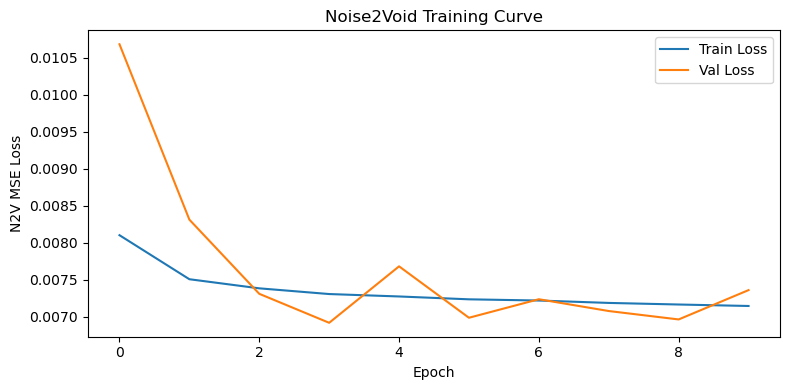

2026-04-20 00:08:54,619 [INFO] Epoch   11/100 | train=0.007135 | val=0.006955 | lr=3.88e-04
2026-04-20 00:55:34,191 [INFO] Epoch   12/100 | train=0.007116 | val=0.006905 | lr=3.86e-04
2026-04-20 00:55:34,645 [INFO]   ✓ Best checkpoint saved (val=0.006905)
2026-04-20 01:41:01,888 [INFO] Epoch   13/100 | train=0.007117 | val=0.006837 | lr=3.84e-04
2026-04-20 01:41:02,502 [INFO]   ✓ Best checkpoint saved (val=0.006837)
2026-04-20 02:26:24,955 [INFO] Epoch   14/100 | train=0.007102 | val=0.006868 | lr=3.81e-04
2026-04-20 03:11:53,136 [INFO] Epoch   15/100 | train=0.007098 | val=0.006860 | lr=3.78e-04
2026-04-20 03:57:20,726 [INFO] Epoch   16/100 | train=0.007084 | val=0.006892 | lr=3.76e-04
2026-04-20 04:42:48,883 [INFO] Epoch   17/100 | train=0.007060 | val=0.006923 | lr=3.72e-04
2026-04-20 05:28:16,600 [INFO] Epoch   18/100 | train=0.007073 | val=0.006817 | lr=3.69e-04
2026-04-20 05:28:17,287 [INFO]   ✓ Best checkpoint saved (val=0.006817)
2026-04-20 06:13:59,611 [INFO] Epoch   19/100 | 

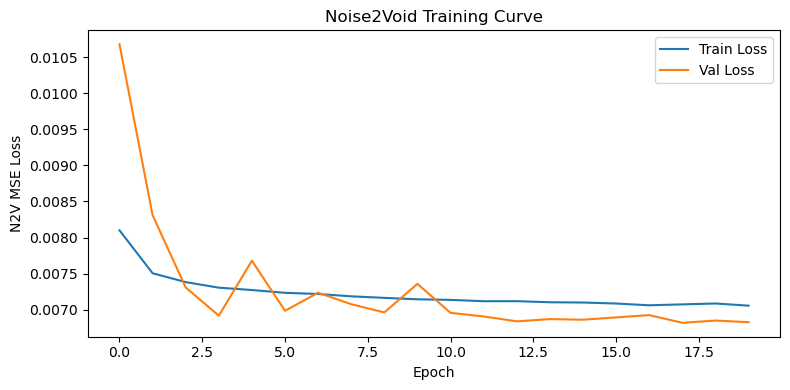

2026-04-20 07:44:41,549 [INFO] Epoch   21/100 | train=0.007063 | val=0.006817 | lr=3.58e-04
2026-04-20 08:30:28,202 [INFO] Epoch   22/100 | train=0.007058 | val=0.006919 | lr=3.55e-04
2026-04-20 09:15:56,437 [INFO] Epoch   23/100 | train=0.007056 | val=0.006891 | lr=3.51e-04
2026-04-20 10:01:54,672 [INFO] Epoch   24/100 | train=0.007045 | val=0.006902 | lr=3.46e-04
2026-04-20 10:48:41,708 [INFO] Epoch   25/100 | train=0.007060 | val=0.006792 | lr=3.42e-04
2026-04-20 10:48:42,194 [INFO]   ✓ Best checkpoint saved (val=0.006792)
2026-04-20 11:35:24,418 [INFO] Epoch   26/100 | train=0.007058 | val=0.006809 | lr=3.38e-04
2026-04-20 12:24:30,627 [INFO] Epoch   27/100 | train=0.007054 | val=0.006909 | lr=3.33e-04
2026-04-20 13:12:55,290 [INFO] Epoch   28/100 | train=0.007041 | val=0.006794 | lr=3.28e-04
2026-04-20 14:00:56,498 [INFO] Epoch   29/100 | train=0.007036 | val=0.006872 | lr=3.23e-04
2026-04-20 14:49:10,045 [INFO] Epoch   30/100 | train=0.007040 | val=0.006861 | lr=3.18e-04


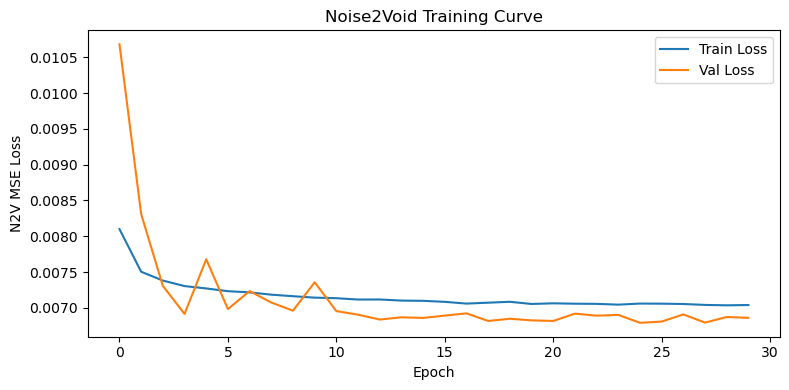

2026-04-20 15:36:40,819 [INFO] Epoch   31/100 | train=0.007024 | val=0.006867 | lr=3.13e-04
2026-04-20 16:23:56,971 [INFO] Epoch   32/100 | train=0.007028 | val=0.006810 | lr=3.08e-04
2026-04-20 17:11:16,957 [INFO] Epoch   33/100 | train=0.007031 | val=0.006942 | lr=3.03e-04
2026-04-20 17:58:43,696 [INFO] Epoch   34/100 | train=0.007020 | val=0.006796 | lr=2.97e-04
2026-04-20 18:47:09,759 [INFO] Epoch   35/100 | train=0.007012 | val=0.006909 | lr=2.92e-04
2026-04-20 19:35:48,243 [INFO] Epoch   36/100 | train=0.007013 | val=0.006825 | lr=2.86e-04
2026-04-20 20:24:03,044 [INFO] Epoch   37/100 | train=0.007010 | val=0.007070 | lr=2.81e-04


KeyboardInterrupt: 

In [21]:
# Run training (comment out if you only want to run inference/eval on an existing checkpoint)
model, history = train(cfg)

## 6. load saved model 

In [16]:
def infer(cfg):
    log.info(f"Inference on: {device}")

    model = N2VUNet(in_channels=1, out_channels=1, base_features=cfg.base_features).to(device)
    state = torch.load(cfg.checkpoint, map_location=device)
    model.load_state_dict(state["model"] if "model" in state else state)
    model.eval()

    input_dir  = Path(cfg.input_dir)
    output_dir = Path(cfg.denoised_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    files = sorted([p for p in input_dir.rglob("*") if p.suffix.lower() in SUPPORTED_EXTS])
    log.info(f"Found {len(files)} images to denoise …")

    for fpath in tqdm(files, desc="Denoising"):
        img = Image.open(fpath).convert("L")
        arr = np.array(img, dtype=np.float32)
        lo, hi = arr.min(), arr.max()
        norm = (arr - lo) / (hi - lo + 1e-8)

        # Pad to multiple of 16 for clean U-Net strides
        H, W = norm.shape
        pad_h = (16 - H % 16) % 16
        pad_w = (16 - W % 16) % 16
        padded = np.pad(norm, ((0, pad_h), (0, pad_w)), mode="reflect")

        t = torch.from_numpy(padded).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(t)
        pred_np = pred.squeeze().cpu().numpy()[:H, :W]

        denoised = np.clip(pred_np, 0, 1) * (hi - lo) + lo
        denoised = denoised.astype(np.uint8 if hi <= 255 else np.uint16)
        Image.fromarray(denoised).save(str(output_dir / fpath.name))

    log.info(f"Denoised images saved to {output_dir}")

In [18]:
# Run inference
infer(cfg)

2026-04-23 17:40:31,331 [INFO] Inference on: mps
2026-04-23 17:40:32,132 [INFO] Found 22 images to denoise …
Denoising: 100%|████████████████████████████████| 22/22 [00:03<00:00,  5.92it/s]
2026-04-23 17:40:35,874 [INFO] Denoised images saved to denoised


## 7. Calculate SNR

In [181]:
from skimage.metrics import peak_signal_noise_ratio as psnr
import cv2

# Load images
clean = cv2.imread('c.png')
noisy = cv2.imread('n.png')

# Calculate PSNR
value = psnr(clean, noisy, data_range=255)
print(f"PSNR: {value} dB")


PSNR: 29.29152375964418 dB


In [207]:
# def calculate_snr(clean_img, noisy_img):
#     # Convert to float to avoid overflow/underflow
#     clean = clean_img.astype(np.float64)/255
#     noisy = noisy_img.astype(np.float64)/255

    
#     signal_power = np.mean(clean)

    
#     noise = clean - noisy
#     noise_power = np.var(noise)

    
#     snr = 10 * np.log10(signal_power / (noise_power))
    
#     return snr

# # Usage
# img_clean = cv2.imread('c.png')
# img_noisy = cv2.imread('n.png')
# print(f"SNR: {calculate_snr(img_clean, img_noisy):.2f} dB")


SNR: 24.45 dB


In [225]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np
from PIL import Image

def load_image(path):
    return np.array(Image.open(path).convert("L"))


img1 = noisy   # nosiy
img2 = clean   # clean 

# # Normalize
img1 = img1.astype(np.float32) / 255.0
img2 = img2.astype(np.float32) / 255.0

# Calculate SNR

# Signal Power: Variance of the clean image (img2)
P_signal = np.var(img2)

# Noise Power: Variance of the difference between denoised and clean image
noise = img1 - img2
P_noise = np.var(noise)

if P_noise == 0:
    print("Noise power is zero, SNR is infinite.")
else:
    snr_value = 10 * np.log10(P_signal / P_noise)
    print("SNR (dB):", snr_value)

SNR (dB): 13.815983533859253
